#  CF Models Training & Comparison

**Goal:** Train and compare 3 Collaborative Filtering models on the 20M Amazon dataset.

**Models:**
- **ALS** (Alternating Least Squares) — implicit library
- **BPR** (Bayesian Personalized Ranking) — implicit library  
- **SVD** (Truncated SVD) — scikit-learn

**Metrics:** HitRate@10, Precision@10, Recall@10, MRR@10, NDCG@10

**Configurations:**
- Data: `configs/data_config.yaml`
- Model: `configs/model_config.yaml`


In [8]:
# Cell 1: Setup and Clean Imports
import os
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Safely resolve project root
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Importing your specific modular functions
from src.utils.config_loader import load_model_config
from mlops.train import *
from src.models.cf_model import*
from mlops.evaluate import evaluate_model_at_k

# Aesthetic settings for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Cell 2: Paths, Configs, and Data Loading (with 2017+ filter)
import os
import pandas as pd

# 1. Define Paths
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
REPORTS_DIR = os.path.join(PROJECT_ROOT, 'reports')
CONFIG_PATH = os.path.join(PROJECT_ROOT, 'configs', 'model_config.yaml')

# Ensure reports directory exists for saving plots and CSVs later
os.makedirs(REPORTS_DIR, exist_ok=True)

# 2. Load Configurations
print("Loading model configurations...")
model_configs = load_model_config(CONFIG_PATH)
print(" Model configurations loaded successfully!")

# 3. Load Datasets
print("Loading parquet datasets...")
train_df = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val_df = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))

print(f"Original Train size: {train_df.shape[0]:,} interactions")

# 4. Filter Data (2017 and newer)
train_df = train_df[train_df['timestamp'] >= '2017-01-01']

print(f"Filtered Train size (2017+): {train_df.shape[0]:,} interactions")
print(f"Validation size: {val_df.shape[0]:,} interactions")

Loading parquet datasets...
Original Train size: 3,695,843 interactions
Filtered Train size (2017+): 2,165,794 interactions
Validation size: 513,482 interactions


In [12]:
# Cell 3: Prepare Sparse Matrices
print("Building aligned sparse matrices...")
train_matrix, val_matrix, users_to_evaluate = prepare_sparse_matrices(train_df, val_df)

print(f"Train Matrix Shape: {train_matrix.shape}")
print(f"Users to Evaluate: {len(users_to_evaluate):,}")

Building aligned sparse matrices...
Train Matrix Shape: (997856, 9880)
Users to Evaluate: 346,743


In [13]:
# Cell 4: Training & Evaluation Pipeline (Robust Version)
def run_recommender_pipeline(model_name: str, configs: dict) -> dict:
    print(f"\n{'='*50}\n Running Pipeline for: {model_name}\n{'='*50}")
    
    # 1. Instantiate Model (Using your Factory methods)
    params = get_model_params(configs, model_name)
    model = get_model(model_name, params)
    
    # 2. Train Model
    print("[1/2] Training Model...")
    start_train = time.time()
    model.fit(train_matrix) 
    train_time = time.time() - start_train
    
    # 3. Evaluate Model
    print(f"[2/2] Evaluating Model at K=10...")
    start_eval = time.time()
    metrics = evaluate_model_at_k(model, val_matrix, users_to_evaluate, k=10)
    eval_time = time.time() - start_eval
    
    # 4. Package Results
    metrics.update({
        'Model': model_name,
        'Train_Time_sec': round(train_time, 2),
        'Eval_Time_sec': round(eval_time, 2)
    })
    
    print(f" {model_name} completed successfully in {train_time + eval_time:.2f} seconds.")
    return metrics


models_list = ['ALS', 'BPR', 'SVD'] 
results = []

for m in models_list:
    try:
        res = run_recommender_pipeline(m, configs=model_configs)
        results.append(res)
    except Exception as e:
        print(f" Failed to execute {m}. Error: {str(e)}")

comparison_df = pd.DataFrame(results)
metric_cols = [c for c in comparison_df.columns if c not in ['Model', 'Train_Time_sec', 'Eval_Time_sec']]
final_cols = ['Model'] + metric_cols + ['Train_Time_sec', 'Eval_Time_sec']
comparison_df = comparison_df[final_cols]

display(comparison_df)


 Running Pipeline for: ALS
[1/2] Training Model...
[INFO] Fitting ALS Model with 64 latent factors...


d:\Ahmed\study\DEPI\tasks\Final_project\recommendation-system\system_env\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:32<00:00,  1.60s/it]


[INFO] ALS Model fitting complete. 
[2/2] Evaluating Model at K=10...


 ALS completed successfully in 180.17 seconds.

 Running Pipeline for: BPR
[1/2] Training Model...
[INFO] Fitting BPR Model with 64 latent factors...


100%|██████████| 100/100 [00:17<00:00,  5.80it/s, train_auc=98.86%, skipped=0.42%]


[INFO] BPR Model fitting complete. 
[2/2] Evaluating Model at K=10...


 BPR completed successfully in 155.88 seconds.

 Running Pipeline for: SVD
[1/2] Training Model...
[INFO] Fitting SVD Model with 64 components...
[INFO] SVD Model fitting complete. ✅
[2/2] Evaluating Model at K=10...


 SVD completed successfully in 950.56 seconds.


,Model,HitRate_10,Precision_10,Adj_Precision_10,Recall_10,MRR_10,NDCG_10,Train_Time_sec,Eval_Time_sec
0,ALS,0.0156,0.0016,0.0107,0.0107,0.0053,0.0057,32.41,147.76
1,BPR,0.0056,0.0006,0.0037,0.0037,0.0020,0.0021,17.65,138.23
2,SVD,0.0139,0.0014,0.0095,0.0095,0.0048,0.0051,13.82,936.74


Results saved to d:\Ahmed\study\DEPI\tasks\Final_project\recommendation-system\reports\model_comparison_results.csv



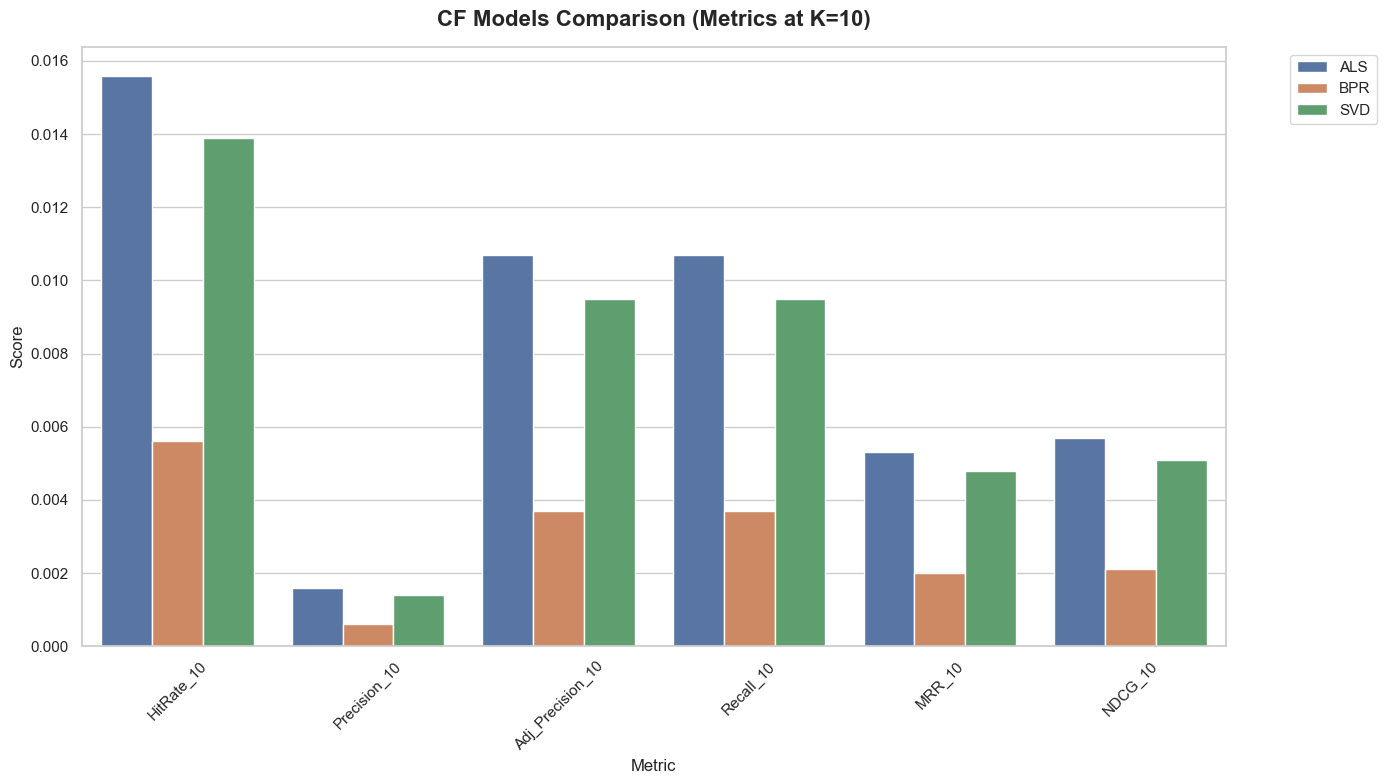

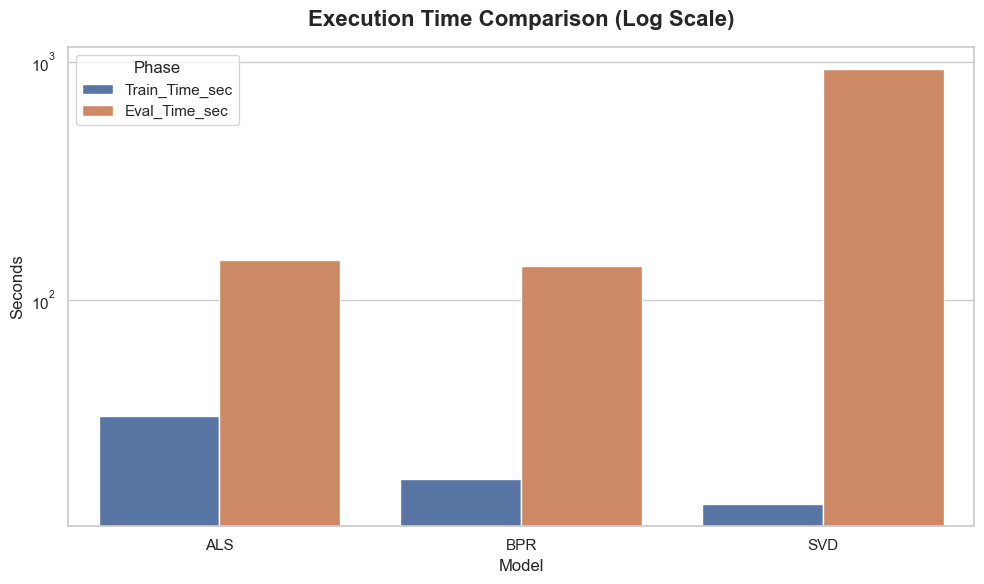

In [14]:
# Cell 5: Save Results and Visualize
csv_path = os.path.join(REPORTS_DIR, 'model_comparison_results.csv')
comparison_df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}\n")

# 1. Plot Metrics Comparison
plot_df = comparison_df.melt(id_vars='Model', value_vars=metric_cols, 
                             var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model')
plt.title('CF Models Comparison (Metrics at K=10)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'model_comparison.png'), dpi=300)
plt.show()

# 2. Plot Execution Times (Log Scale for KNN)
time_plot_df = comparison_df.melt(id_vars='Model', value_vars=['Train_Time_sec', 'Eval_Time_sec'], 
                                  var_name='Phase', value_name='Seconds')

plt.figure(figsize=(10, 6))
sns.barplot(data=time_plot_df, x='Model', y='Seconds', hue='Phase')
plt.title('Execution Time Comparison (Log Scale)', fontsize=16, fontweight='bold', pad=15)
plt.yscale('log') # Crucial for ItemKNN
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'model_time_comparison.png'), dpi=300)
plt.show()